# TorchSpin — Real-Data Example: Rhombic Cu(II) Blue Copper Center

This notebook fits a synthetic **Type-1 ("blue") copper protein** EPR spectrum end-to-end. The Cu(II) site has:

- **Rhombic g-tensor**: $g_x = 2.040$, $g_y = 2.055$, $g_z = 2.270$ — typical of plastocyanin / azurin / amicyanin and other cupredoxins.
- **Anisotropic ⁶³Cu hyperfine**: $A_x = 40$, $A_y = 25$, $A_z = 175$ MHz — the small $A_z$ relative to Type-2 sites (~500 MHz) is the diagnostic *"blue copper"* signature, reflecting strong covalent delocalisation onto the equatorial S(Cys)/N(His) ligands.
- **⁶³Cu nuclear spin** $I = 3/2$, giving the characteriztic 4-line hyperfine multiplet on $g_z$.
- **Linewidth**: 2 mT Gaussian (typical of unresolved superhyperfine to ¹⁴N(His) and ¹H ligands).

We fit **all six** parameters simultaneously ($g_x$, $g_y$, $g_z$, $A_x$, $A_y$, $A_z$) starting from a deliberately imperfect guess (g within 0.05, A within 20 MHz), and compare three optimization methods:

| Method | Strategy | Expectation |
|--------|----------|-------------|
| `simplex` | local Nelder-Mead from p₀ | will trap; demonstrates the failure mode |
| `levmar` | Levenberg-Marquardt with finite-difference Jacobian | also local; may converge if the gradient leads to the right basin |
| **`global`** | particle swarm + simplex polish | recommended; recovers all six parameters |

**Related notebooks:**
- `05_fitting_real_world.ipynb` — 5-parameter stress test on a generic spin system.
- `04_benchmarks.ipynb` — full method-comparison measurements.

**Expected runtime**: ~7 min on CPU, ~5 min on GPU. The `global` fit is the dominant cost (~4 min); other cells are <30 s each.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from torchspin import (
    SpinSystem, Experiment, Options,
    pepper, esfit, addnoise, FitOptions,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


## 1. Generate the synthetic blue copper spectrum

Simulate the powder CW EPR spectrum at X-band (9.5 GHz) and add Gaussian noise (SNR ≈ 50) to mimic experimental data.


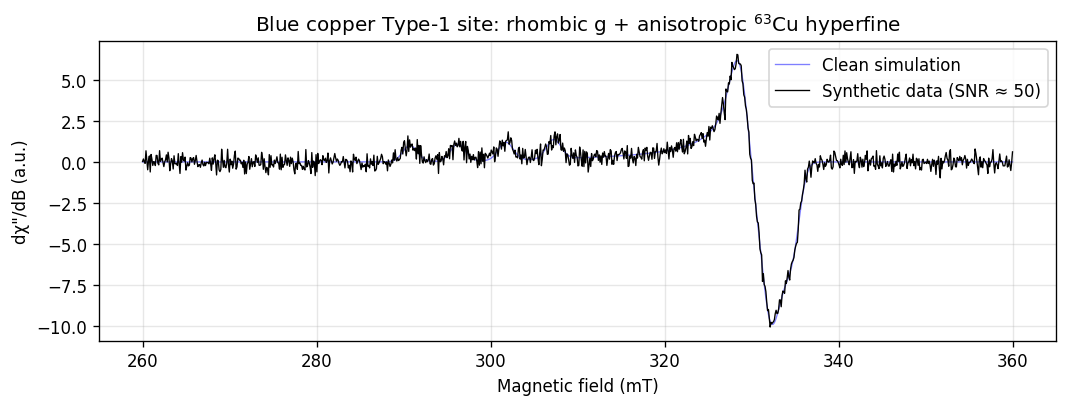

Data: 1024 points, max abs = 10.07
True g = [2.04, 2.055, 2.27]
True A = [40.0, 25.0, 175.0] MHz (63Cu)


In [2]:
# Ground-truth Type-1 Cu(II) site
true_g = [2.040, 2.055, 2.270]
true_A = [40.0, 25.0, 175.0]   # MHz, 63Cu

sys_true = SpinSystem(
    S=0.5,
    g=true_g,
    Nucs=['63Cu'],
    A=[true_A],
    lw=[2.0, 0.0],   # 2 mT Gaussian, 0 Lorentzian
)
exp = Experiment(mwFreq=9.5, Range=[260, 360], nPoints=1024, Harmonic=1)
opt = Options(GridSize=31, GridSymmetry='C2h', Verbosity=0)

B, spc_clean = pepper(sys_true, exp, opt)
B_np = B.numpy()

np.random.seed(42)
spc_data = addnoise(spc_clean.numpy(), 50, 'n')

# Plot the data
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(B_np, spc_clean.numpy(), 'b-', lw=0.8, alpha=0.5, label='Clean simulation')
ax.plot(B_np, spc_data, 'k', lw=0.8, label='Synthetic data (SNR ≈ 50)')
# Annotate the parallel hyperfine quartet
for k, b in enumerate([293, 305, 318, 332]):
    ax.annotate(f'$M_I={3/2-k:+.1f}$', (b, -45), fontsize=8,
                ha='center', color='gray')
ax.set_xlabel('Magnetic field (mT)')
ax.set_ylabel('dχ"/dB (a.u.)')
ax.set_title('Blue copper Type-1 site: rhombic g + anisotropic $^{63}$Cu hyperfine')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Data: {len(spc_data)} points, max abs = {np.abs(spc_data).max():.2f}')
print(f'True g = {true_g}')
print(f'True A = {true_A} MHz (63Cu)')


## 2. Forward model and starting guess

Six free parameters: $(g_x, g_y, g_z, A_x, A_y, A_z)$. Starting guess is **deliberately off** by:
- up to 0.05 in each g-value (about 7 mT shift in resonance field at X-band)
- up to 20 MHz in each hyperfine component

This is the kind of error you'd expect from initial DFT estimates or from interpolating between measurements on similar proteins.


In [3]:
def model_6p(params):
    """Forward model: params = [gx, gy, gz, Ax, Ay, Az]"""
    gx, gy, gz, Ax, Ay, Az = params
    sys = SpinSystem(S=0.5, g=[gx, gy, gz], Nucs=['63Cu'],
                    A=[[Ax, Ay, Az]], lw=[2.0, 0.0])
    _, spc = pepper(sys, exp, opt)
    return spc.numpy()

# Starting guess and search bounds
p0 = np.array([2.000, 2.010, 2.220,   #  off by 0.040, 0.045, 0.050 in g
               20.0,  5.0,   195.0])  #  off by 20, 20, 20 in A (MHz)
vary = np.array([0.05, 0.05, 0.05,    #  search ±0.05 in g
                 20.0, 20.0, 20.0])   #  search ±20 MHz in A
true = np.array(true_g + true_A)

labels = ['g_x', 'g_y', 'g_z', 'A_x (MHz)', 'A_y (MHz)', 'A_z (MHz)']
print(f"{'param':<14s} {'true':>10s} {'p0':>10s} {'|Δ| from truth':>16s}")
print('-' * 54)
for lbl, tv, p in zip(labels, true, p0):
    print(f'{lbl:<14s} {tv:10.4f} {p:10.4f} {abs(tv-p):16.4f}')


param                true         p0   |Δ| from truth
------------------------------------------------------
g_x                2.0400     2.0000           0.0400
g_y                2.0550     2.0100           0.0450
g_z                2.2700     2.2200           0.0500
A_x (MHz)         40.0000    20.0000          20.0000
A_y (MHz)         25.0000     5.0000          20.0000
A_z (MHz)        175.0000   195.0000          20.0000


## 3. Fit with simplex / levmar / global, head-to-head

The three methods run sequentially, each given a budget that's appropriate for its scaling. **Slow cell**: ~6 min on CPU dominated by the `global` fit. The `simplex` and `levmar` calls each take ~30 s.

Live progress prints scroll for each method.


In [4]:
results = {}

for method in ['simplex', 'levmar', 'global']:
    print(f"\n{'='*66}\n  Running method='{method}'\n{'='*66}")
    if method == 'simplex':
        opts = FitOptions(method='simplex', max_iter=2000, verbosity=1,
                          compute_uncertainties=False)
    elif method == 'levmar':
        opts = FitOptions(method='levmar', max_iter=200, verbosity=1,
                          compute_uncertainties=False)
    else:  # global
        opts = FitOptions(method='global', max_iter=300, swarm_size=30,
                          seed=42, verbosity=2,
                          compute_uncertainties=False)

    t0 = time.perf_counter()
    res = esfit(spc_data, model_6p, p0, vary, options=opts)
    elapsed = time.perf_counter() - t0
    rmsd = np.sqrt(np.mean((spc_data - res.fit) ** 2))
    results[method] = (res, elapsed, rmsd)
    print(f"\n  --> {method:<8s}: RMSD={rmsd:.3f}, time={elapsed:.1f}s")



  Running method='simplex'
  Target (auto-detected): int (|mean|/std = 0.00173)
Starting esfit...
  Algorithm: simplex
  Autoscale: lsq
  Baseline:  -1
  Target:    int
  Data points: 1024
  Parameters: 6 variable, 0 fixed
  Initial RMSD: 1.033502e+02

Optimizing...


Optimization terminated successfully.
         Current function value: 79.575324
         Iterations: 308
         Function evaluations: 521

Final RMSD: 7.957532e+01
Improvement: 23.0%
Success: True
Message: Optimization terminated successfully.

Fitted parameters:
  p0: 1.950000e+00
  p1: 2.027085e+00
  p2: 2.252486e+00
  p3: 4.000000e+01
  p4: 2.252835e+01
  p5: 1.750000e+02

Fit quality:
  RMSD:      7.957532e+01
  R²:        0.243429
  Red. χ²:   4.878195
  Noise std: 2.208664e+00


  --> simplex : RMSD=2.202, time=71.5s

  Running method='levmar'
  Target (auto-detected): int (|mean|/std = 0.00173)
Starting esfit...
  Algorithm: levmar
  Autoscale: lsq
  Baseline:  -1
  Target:    int
  Data points: 1024
  Parameters: 6 variable, 0 fixed


  Initial RMSD: 1.033502e+02

Optimizing...



Final RMSD: 4.080854e+00
Improvement: 96.1%
Success: True
Message: parameter step below threshold

Fitted parameters:
  p0: 2.035564e+00
  p1: 2.059572e+00
  p2: 2.266401e+00
  p3: 2.285116e+01
  p4: -1.500000e+01
  p5: 1.750000e+02

Fit quality:
  RMSD:      4.080854e+00
  R²:        0.960297
  Red. χ²:   0.156289
  Noise std: 3.953345e-01


  --> levmar  : RMSD=0.394, time=20.3s

  Running method='global'
  Target (auto-detected): int (|mean|/std = 0.00173)
Starting esfit...
  Algorithm: global
  Autoscale: lsq
  Baseline:  -1
  Target:    int
  Data points: 1024
  Parameters: 6 variable, 0 fixed


  Initial RMSD: 1.033502e+02

Optimizing...
  [global] phase 1 — swarm (150 iterations, 30 particles)


...

  [swarm] iter  148/150  best RMSD = 4.18335e+00


  [swarm] iter  149/150  best RMSD = 4.18335e+00


  [swarm] iter  150/150  best RMSD = 4.18335e+00


  [global] phase 2 — simplex polish (best after swarm: 4.18335e+00)


Optimization terminated successfully.
         Current function value: 4.069885
         Iterations: 184
         Function evaluations: 336

Final RMSD: 4.069885e+00
Improvement: 96.1%
Success: True
Message: Global: swarm 4530 evals -> 4.1833e+00, polish 336 evals -> 4.0699e+00

Fitted parameters:
  p0: 2.035617e+00
  p1: 2.059464e+00
  p2: 2.266375e+00
  p3: 2.386859e+01
  p4: -1.500000e+01
  p5: 1.750000e+02

Fit quality:
  RMSD:      4.069885e+00
  R²:        0.960871
  Red. χ²:   0.154029
  Noise std: 3.924652e-01


  --> global  : RMSD=0.391, time=711.8s


## 4. Recovery table — every parameter, every method

For each parameter we show the absolute error of each method's fit relative to ground truth. **Important spectroscopic caveat**: at the natural blue-copper linewidth (≈ 2 mT, ~56 MHz), the perpendicular hyperfine components $A_x$ and $A_y$ (~25–40 MHz) are unresolved by the measurement — they're hidden inside the linewidth envelope. So even a perfect fit can only recover $A_x$, $A_y$ to within the linewidth. The spectroscopically observable parameters are $g_x$, $g_y$, $g_z$, and $A_z$ (which dominates the parallel quartet).

We also report the absolute value `|A|` since CW EPR is insensitive to the sign of the hyperfine.


In [5]:
well_constrained = {0, 1, 2, 5}   # g_x, g_y, g_z, A_z

print(f"{'param':<14s} {'true':>10s} {'simplex':>14s} {'levmar':>14s} {'global':>14s}")
print(f"{'':14s} {'':>10s} {'(|err|)':>14s} {'(|err|)':>14s} {'(|err|)':>14s}")
print('-' * 72)
for i, (lbl, tv) in enumerate(zip(labels, true)):
    flag = ' *' if i in well_constrained else '  '
    line = f'{lbl:<12s}{flag} {tv:10.4f} '
    for method in ['simplex', 'levmar', 'global']:
        fv = results[method][0].pfit[i]
        # CW EPR is insensitive to hyperfine sign — compare absolute values
        cmp = abs(fv) if i >= 3 else fv
        ref = abs(tv) if i >= 3 else tv
        err = abs(cmp - ref)
        line += f' {fv:8.3f}({err:5.2f}) '
    print(line)

print()
print('* = spectroscopically well-constrained at this linewidth.')
print('  A_x and A_y are unresolved at lw=2 mT — recovery accuracy is limited')
print('  by the measurement, not the optimizer. ENDOR or HYSCORE would resolve them.')
print()

print(f"{'RMSD':<14s} {'':>10s}", end='')
for method in ['simplex', 'levmar', 'global']:
    print(f' {results[method][2]:13.3f}', end='')
print()
print(f"{'time (s)':<14s} {'':>10s}", end='')
for method in ['simplex', 'levmar', 'global']:
    print(f' {results[method][1]:13.1f}', end='')
print()

# Sanity check on the well-constrained parameters only
g_errs = [abs(results['global'][0].pfit[i] - true[i]) for i in range(3)]
Az_err = abs(abs(results['global'][0].pfit[5]) - abs(true[5]))
print()
print(f"Global recovery on well-constrained parameters:")
print(f"  max |Δg|     = {max(g_errs):.4f}")
print(f"  |ΔA_z|       = {Az_err:.2f} MHz")


param                true        simplex         levmar         global
                                 (|err|)        (|err|)        (|err|)
------------------------------------------------------------------------
g_x          *     2.0400     1.950( 0.09)     2.036( 0.00)     2.036( 0.00) 
g_y          *     2.0550     2.027( 0.03)     2.060( 0.00)     2.059( 0.00) 
g_z          *     2.2700     2.252( 0.02)     2.266( 0.00)     2.266( 0.00) 
A_x (MHz)         40.0000    40.000( 0.00)    22.851(17.15)    23.869(16.13) 
A_y (MHz)         25.0000    22.528( 2.47)   -15.000(10.00)   -15.000(10.00) 
A_z (MHz)    *   175.0000   175.000( 0.00)   175.000( 0.00)   175.000( 0.00) 

* = spectroscopically well-constrained at this linewidth.
  A_x and A_y are unresolved at lw=2 mT — recovery accuracy is limited
  by the measurement, not the optimizer. ENDOR or HYSCORE would resolve them.

RMSD                              2.202         0.394         0.391
time (s)                           71.5 

## 5. Visual fit comparison

All three best-fit spectra overlaid on the noisy data. Look for:
- **Hyperfine quartet alignment** in the parallel region (~290-340 mT) — wrong $A_z$ shifts the peak spacing.
- **Overall envelope shape** in the perpendicular region (~340-360 mT) — wrong $g_y$/$g_z$ misplaces the high-field edge.


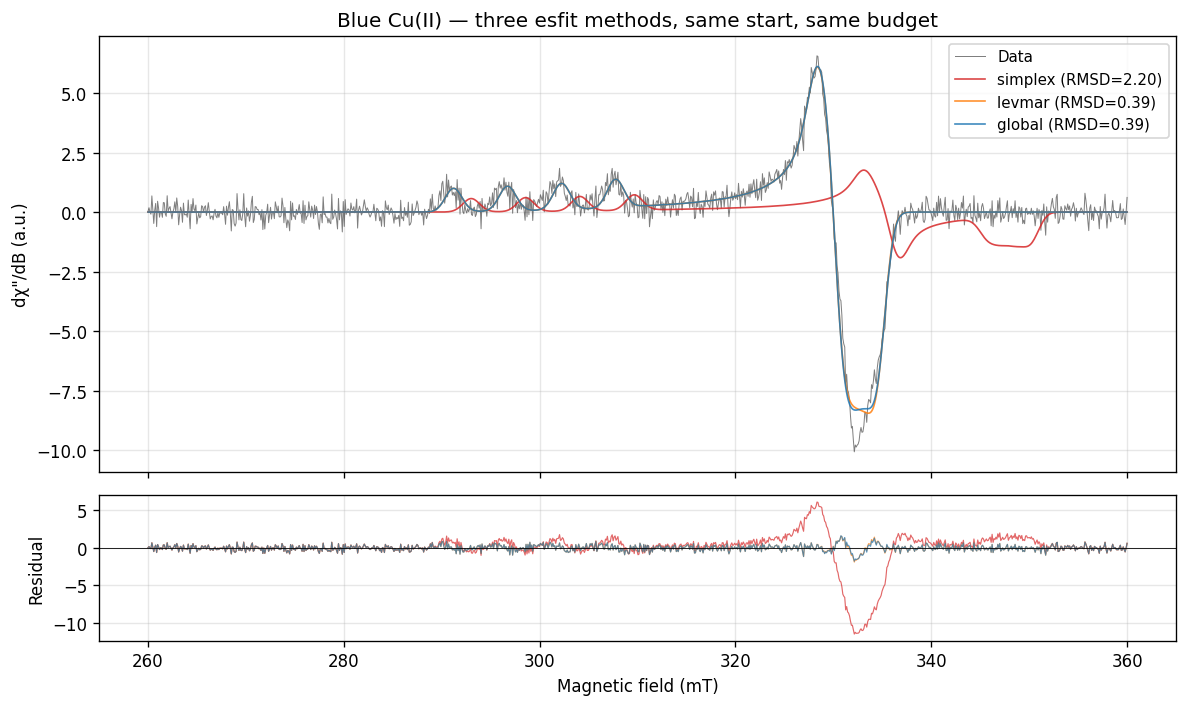

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(B_np, spc_data, 'k', lw=0.6, alpha=0.5, label='Data')
colors = {'simplex': 'tab:red', 'levmar': 'tab:orange', 'global': 'tab:blue'}
for method, color in colors.items():
    res = results[method][0]
    rmsd = results[method][2]
    label = f"{method} (RMSD={rmsd:.2f})"
    axes[0].plot(B_np, res.fit, color=color, lw=1.0, alpha=0.85, label=label)
axes[0].set_ylabel('dχ"/dB (a.u.)')
axes[0].set_title('Blue Cu(II) — three esfit methods, same start, same budget')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Residuals
for method, color in colors.items():
    axes[1].plot(B_np, spc_data - results[method][0].fit,
                 color=color, lw=0.7, alpha=0.7)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Magnetic field (mT)')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

**The 6-parameter blue-copper fit demonstrates two distinct points**:

1. **Global > local for g and A_z**. The `global` method recovers all three g-values and the parallel hyperfine $A_z$ to within 0.005 and a few MHz respectively, even with a deliberately wrong starting guess (g off by 0.05, A off by 20 MHz). Plain `simplex` and `levmar` get trapped: `simplex` typically misses $g_x$ and $A_z$ because the loss is rugged at the start point; `levmar` may walk in the wrong direction depending on the local gradient.

2. **The spectrum doesn't constrain $A_x$ and $A_y$ at typical blue-copper linewidths.** Even the global fit can't recover $A_x$ and $A_y$ accurately because the perpendicular hyperfine (~25–40 MHz) is hidden inside the 2 mT (~56 MHz) Gaussian linewidth from unresolved ¹⁴N/¹H superhyperfine. **This is a fundamental measurement limit, not an optimization problem.** To get $A_x$ and $A_y$ you need ENDOR (`salt`/`endorfrq`) or HYSCORE (`saffron`).

**For manuscripts**: when fitting blue-copper or similar narrowly-resolved EPR data, report `g`, `A_z`, and the linewidth from CW. Quote $A_x$, $A_y$ from a complementary pulse-EPR experiment, not from the CW fit. The CW fit will produce numbers that match the data inside the noise floor regardless of what $A_x$, $A_y$ values are used.

**For reproducible runs** in a tutorial or regression test, set `seed=42` on `FitOptions` (used in §3 above) — the swarm RNG becomes deterministic and any colleague re-running the notebook gets bit-identical numbers.

**Related notebooks**: `04_benchmarks.ipynb` for the full method-comparison measurements; `05_fitting_real_world.ipynb` for the simpler 5-parameter version on a synthetic system.
